In [5]:
import numpy as np
import pandas as pd 
import matplotlib
import matplotlib.pyplot as plt 
%matplotlib inline
from urllib.request import urlretrieve

In [7]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

print("Shape of X_train:", X_train.shape)


11490434/11490434 [==============================] - 3s 0us/step
Shape of X_train: (60000, 784)


In [10]:
X, y = X_train, y_train

print(X.shape, y.shape)

(60000, 784) (60000,)


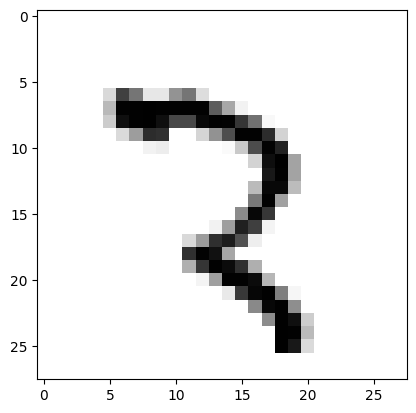

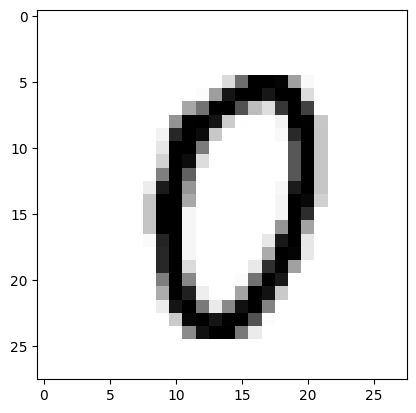

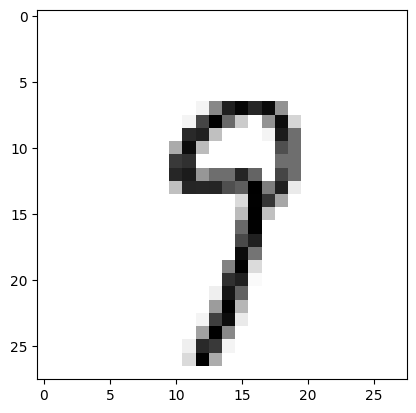

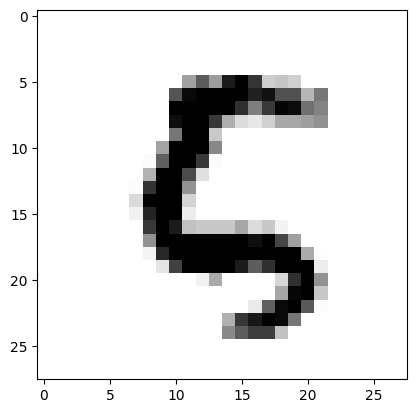

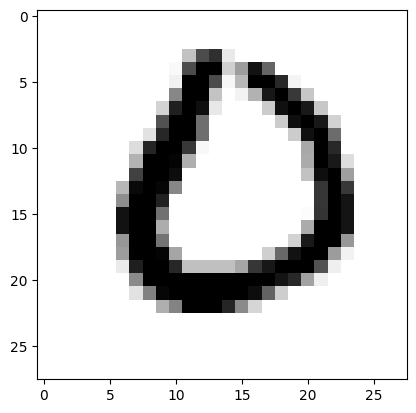

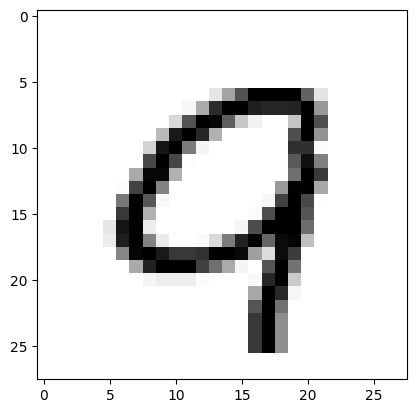

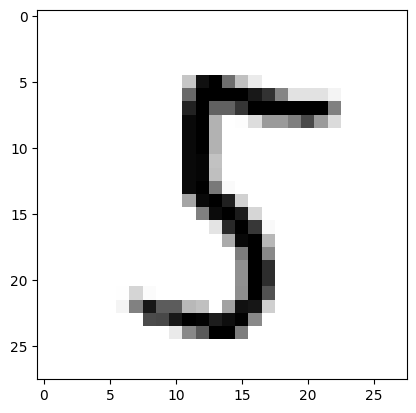

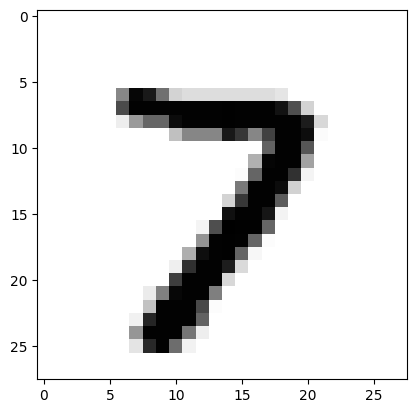

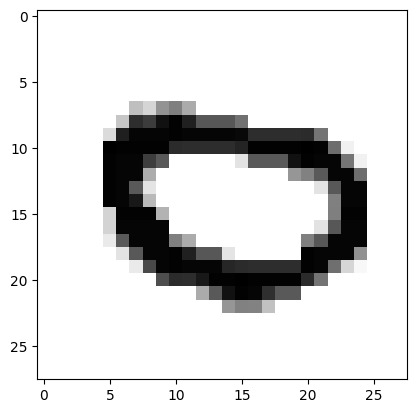

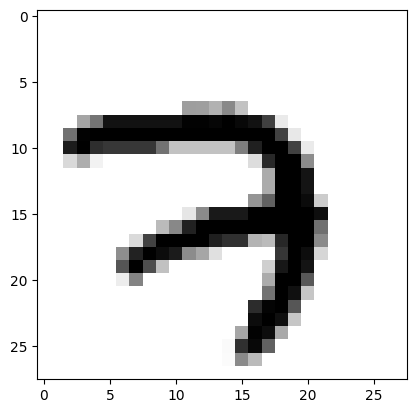

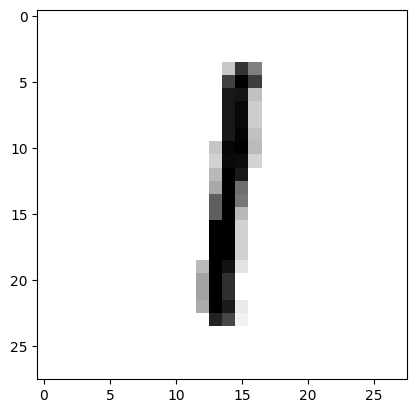

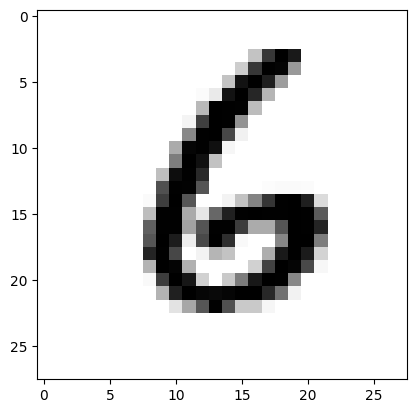

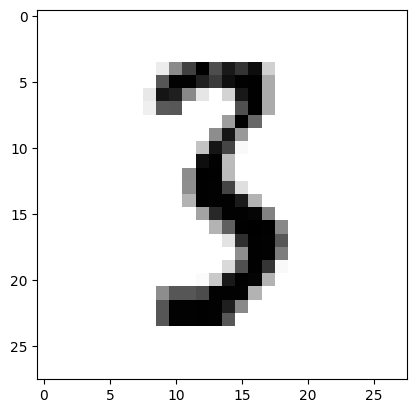

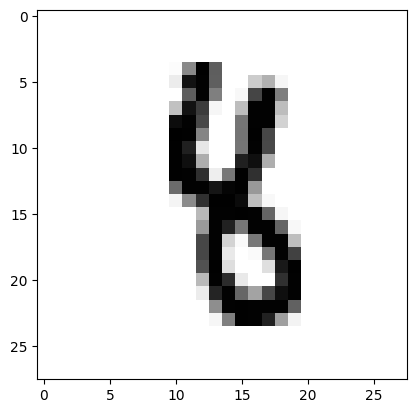

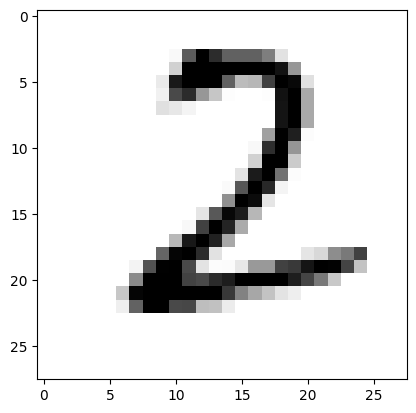

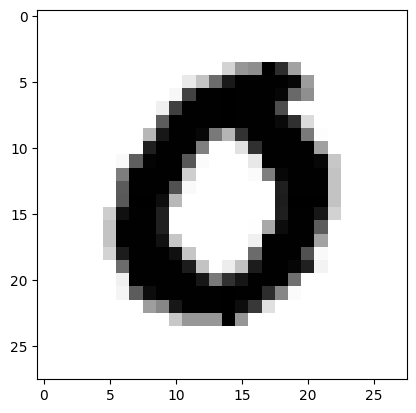

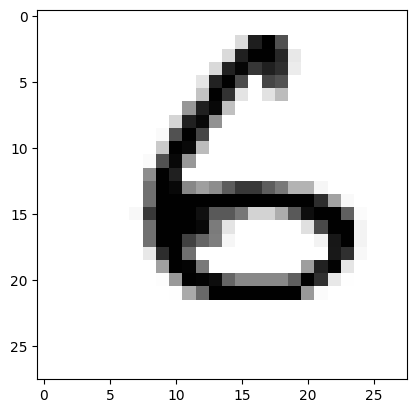

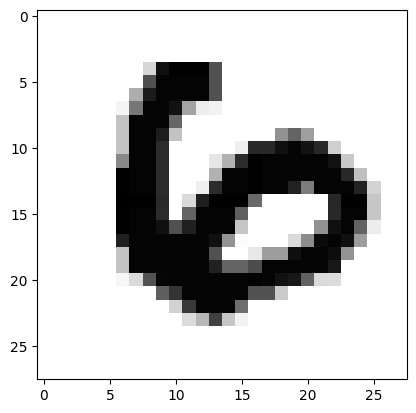

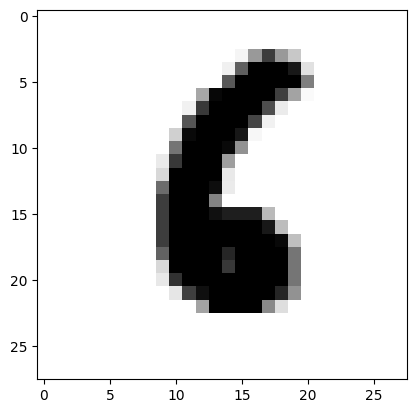

In [11]:
for i in range(500, 10000, 500):
    digit = X[i]
    digit = digit.reshape(28, 28)
    
    plt.figure()
    plt.imshow(digit, cmap=matplotlib.cm.binary)

plt.show()

In [12]:
train_x , test_x = X[:10000],X[10000:] 
train_y , test_y = y[:10000],y[10000:]

In [13]:
shuffle_index = np.random.permutation(10000) 
train_X , train_y = train_x[shuffle_index] , train_y[shuffle_index] 

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

In [20]:

train_X = train_X / 255.0
test_x = test_x / 255.0

### 1.Logistic Regression

In [21]:
logreg = LogisticRegression(random_state=1, max_iter=1000)
logreg.fit(train_X, train_y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [22]:
from sklearn.model_selection import cross_val_score

score_logreg = cross_val_score(logreg, train_X, train_y,cv=5)
print(score_logreg)

[0.9015 0.9065 0.903  0.9125 0.905 ]


In [23]:
accuracy = np.mean(score_logreg)
accuracy

0.9057000000000001

### 2. Random Forest

In [24]:
rfc=RandomForestClassifier(random_state=42)

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_features': ['sqrt', 'log2'], 
    'max_depth' : [4, 5, 6, 7, 8],
    'criterion' :['gini', 'entropy']
}

In [29]:
from sklearn.model_selection import GridSearchCV
CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv= 5)
CV_rfc.fit(train_X, train_y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [4, 5, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and par

In [30]:
CV_rfc.best_params_

{'criterion': 'entropy',
 'max_depth': 8,
 'max_features': 'sqrt',
 'n_estimators': 500}

In [32]:
random_forest = RandomForestClassifier(n_estimators=500,criterion='entropy',max_depth=15,max_features='sqrt', random_state=1)
random_forest.fit(train_X, train_y)

random_forest.score(test_x, test_y)

0.94844

### Deep learning : 

# 3 Layer Feed Forward Neural Network


In [33]:
!pip install torch torchvision --quiet


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import torch
import torchvision
from torchvision.datasets import MNIST
import torchvision.transforms as transforms

dataset = MNIST(root='Dataset/' , download = True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:03<00:00, 2.73MB/s]


Extracting Dataset/MNIST\raw\train-images-idx3-ubyte.gz to Dataset/MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 70.4kB/s]


Extracting Dataset/MNIST\raw\train-labels-idx1-ubyte.gz to Dataset/MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:05<00:00, 289kB/s] 


Extracting Dataset/MNIST\raw\t10k-images-idx3-ubyte.gz to Dataset/MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.48kB/s]

Extracting Dataset/MNIST\raw\t10k-labels-idx1-ubyte.gz to Dataset/MNIST\raw



In [35]:
dataset[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

So, it is stored as image and it is 28x28 as we know and the 5 at the end is the target/label.

5


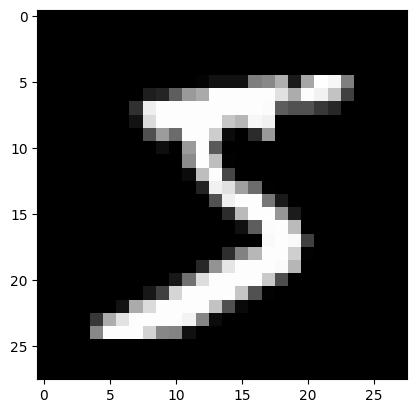

In [36]:
import matplotlib.pyplot as plt
%matplotlib inline

image , label = dataset[0]
plt.imshow(image, cmap='gray')
print(label)

In [37]:
import torchvision.transforms as transforms
from torch.utils.data import random_split

dataset = MNIST(root='Dataset/' ,
        train=True,
        transform= transforms.ToTensor())  #### directly converting into tensors to work with pyTorch
train_ds , val_ds = random_split(dataset , [50000 , 10000])
len(train_ds) , len(val_ds)

(50000, 10000)

In [38]:
from torch.utils.data import DataLoader

batch_size = 200

train_loader = DataLoader(train_ds , batch_size , shuffle=True)
val_loader = DataLoader(val_ds , batch_size)

images.shape torch.Size([200, 1, 28, 28])


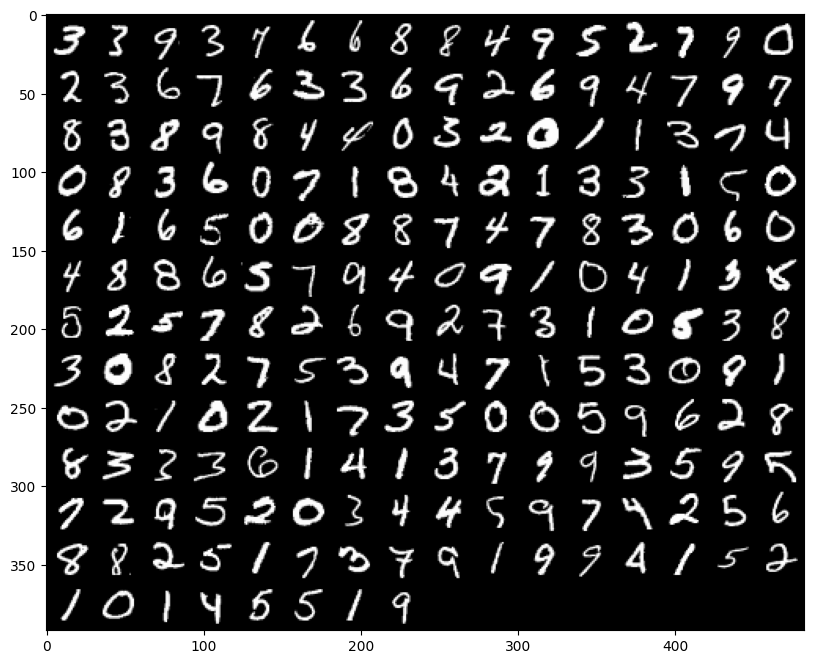

In [39]:
from torchvision.utils import make_grid

for images , _ in train_loader:
    plt.figure(figsize=(16,8))
    print('images.shape' , images.shape)
    plt.imshow(make_grid(images , nrow=16).permute(1,2,0)) # using the permute is necessary step
    break

In [40]:
import torch.nn as nn
import torch.nn.functional as F

In [41]:
class MNISTModel(nn.Module) :
    """Feed Forward neural network with 3 layers."""

    def __init__(self, in_size, hidden_size, out_size):
        super().__init__()
        self.linear1 = nn.Linear(input_size , hidden_size)
        #output layer
        self.linear2 = nn.Linear(hidden_size , num_classes)

    def forward(self , xb) :
        #flattern the image tensors 
        xb = xb.view(xb.size(0), -1)
        #1st layer
        output = self.linear1(xb)
        #activation
        output = F.relu(output)
        #outputlayer
        output = self.linear2(output)
        return output

    def training_step(self, batch):
        images, labels = batch 
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
    
    def validation_step(self, batch):
        images, labels = batch 
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss, 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result['val_loss'], result['val_acc']))

In [42]:
def accuracy(outputs , labels) :
    _, preds = torch.max(outputs , dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [43]:
input_size = 784
hidden_size = 64
num_classes = 10

In [44]:
model = MNISTModel(input_size , hidden_size , out_size= num_classes)

In [45]:
def evaluate(model, val_loader):
    """Evaluate the model's performance on the validation set"""
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    """Train the model using gradient descent"""
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training Phase 
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Validation phase
        result = evaluate(model, val_loader)
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [46]:
# let's see the initial accuracy
history = [evaluate(model, val_loader)]
history

[{'val_loss': 2.304636001586914, 'val_acc': 0.13979999721050262}]

In [47]:
history += fit(10, 0.5, model, train_loader, val_loader)

Epoch [0], val_loss: 0.2334, val_acc: 0.9332
Epoch [1], val_loss: 0.1659, val_acc: 0.9521
Epoch [2], val_loss: 0.1451, val_acc: 0.9557
Epoch [3], val_loss: 0.1251, val_acc: 0.9650
Epoch [4], val_loss: 0.1173, val_acc: 0.9647
Epoch [5], val_loss: 0.1056, val_acc: 0.9681
Epoch [6], val_loss: 0.1086, val_acc: 0.9697
Epoch [7], val_loss: 0.1001, val_acc: 0.9713
Epoch [8], val_loss: 0.1029, val_acc: 0.9700
Epoch [9], val_loss: 0.0926, val_acc: 0.9734


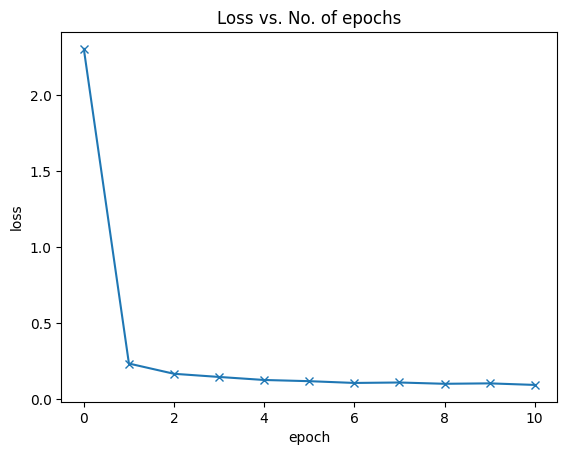

In [49]:
losses = [x['val_loss'] for x in history]
plt.plot(losses, '-x')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss vs. No. of epochs');

# Summarising Results 

In [54]:
results = pd.DataFrame({
    'Logistic Regression': 91,
    'Random Forest': 95,
    '3 Layer Neural Network_64': 97,
    '3 Layer Neural Network_128': 97
},index=['Validation Accuracy'])



In [55]:
results.T.sort_values('Validation Accuracy',ascending=False)

,Validation Accuracy
3 Layer Neural Network_64,97
3 Layer Neural Network_128,97
Random Forest,95
Logistic Regression,91


### Training The Model On Entire Dataset 

In [56]:
batch_size = 200

train_loader = DataLoader(dataset , batch_size , shuffle=True)
test_dataset = MNIST(root='Dataset/' , train=False, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset , batch_size)

In [57]:
model = MNISTModel(input_size , hidden_size , out_size= num_classes)

In [58]:
history = [evaluate(model, test_loader)]
history

[{'val_loss': 2.2974395751953125, 'val_acc': 0.13979999721050262}]

In [59]:
history += fit(15, 0.5, model, train_loader, test_loader)

Epoch [0], val_loss: 0.2028, val_acc: 0.9414
Epoch [1], val_loss: 0.1604, val_acc: 0.9525
Epoch [2], val_loss: 0.1242, val_acc: 0.9615
Epoch [3], val_loss: 0.1065, val_acc: 0.9670
Epoch [4], val_loss: 0.1000, val_acc: 0.9697
Epoch [5], val_loss: 0.0943, val_acc: 0.9711
Epoch [6], val_loss: 0.0925, val_acc: 0.9714
Epoch [7], val_loss: 0.0869, val_acc: 0.9736
Epoch [8], val_loss: 0.0829, val_acc: 0.9749
Epoch [9], val_loss: 0.0788, val_acc: 0.9745
Epoch [10], val_loss: 0.0790, val_acc: 0.9747
Epoch [11], val_loss: 0.0812, val_acc: 0.9744
Epoch [12], val_loss: 0.0799, val_acc: 0.9759
Epoch [13], val_loss: 0.0872, val_acc: 0.9729
Epoch [14], val_loss: 0.0836, val_acc: 0.9753


# Saving The Model

In [61]:
import os

os.makedirs('Model', exist_ok=True)
torch.save(model.state_dict(), 'Model/feedforward3layer_64.pth')